In [2]:
# Import libraries
library(readr)
library(dplyr)
library(ggplot2)

# Yearly Water Billing

In [3]:
# Read CSV file
waterDF <- read_csv("../../data/dataverse_files/Water_Billing.csv")
# Summary of the data
glimpse(waterDF)

Rows: 3 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (6): Year, Flat Water, Sewer Pacel, Sewer Use, Garbage Disposal Fee, Tot...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 3
Columns: 6
$ Year                   <dbl> 2012, 2013, 2014
$ `Flat Water`           <dbl> 512.88, 543.65, 573.55
$ `Sewer Pacel`          <dbl> 482.64, 511.60, 539.74
$ `Sewer Use`            <dbl> 0, 0, 0
$ `Garbage Disposal Fee` <dbl> 0, 75, 75
$ `Total Fees`           <dbl> 995.52, 1130.25, 1188.29


# Whole House Water Metering

In [76]:
# Read CSV file
whwDF <- read_csv("../../data/dataverse_files/Water_WHW.csv")
# Summary of the data
glimpse(whwDF)

Rows: 1051200 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl (4): unix_ts, counter, avg_rate, inst_rate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 1,051,200
Columns: 4
$ unix_ts   <dbl> 1333263600, 1333263660, 1333263720, 1333263780, 1333263840, …
$ counter   <dbl> 45287.53, 45291.31, 45291.31, 45291.31, 45295.10, 45295.10, …
$ avg_rate  <dbl> 0.000, 3.785, 0.000, 0.000, 3.785, 0.000, 0.000, 0.000, 0.00…
$ inst_rate <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, …


In [77]:
# Columns transformation
# Timestamp splitted into different columns (year, month, day, hour, minute) 
# Goal: Will be usefull for aggregation and visualization later
whwDF <- whwDF %>%  
    # Add derived columns
    mutate(
        ts = as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"),
        year = format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%Y"),
        month = format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%m"),
        day = format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%d"),
        date = as.Date(format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%Y-%m-%d"), format = "%Y-%m-%d"),
        hour = format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%H"),
        minute = format(as.POSIXct(unix_ts, origin = "1970-01-01 12:00:00"), format = "%M")
    ) %>%
    # Remove original timestamp column
    select(-unix_ts)

In [79]:
# Find min and max date per year to understand the data better
whwDF %>%
    group_by(year) %>%
    summarise(
        minMonth = min(month),
        maxMonth = max(month)
    )

year,minMonth,maxMonth
<chr>,<chr>,<chr>
2012,04,12
2013,01,12
2014,01,04


In [34]:
whwByDateHourDF <- whwDF %>%
    group_by(date, hour) %>%
    summarise(
        waterCons = sum(avg_rate)
    )

whwByDateDF <- whwDF %>%
    group_by(year, date) %>%
    summarise(
        waterCons = sum(avg_rate)
    )

`summarise()` has grouped output by 'date'. You can override using the
`.groups` argument.
`summarise()` has grouped output by 'year'. You can override using the
`.groups` argument.


In [39]:
library("scales")


Attachement du package : ‘scales’


L'objet suivant est masqué depuis ‘package:readr’:

    col_factor




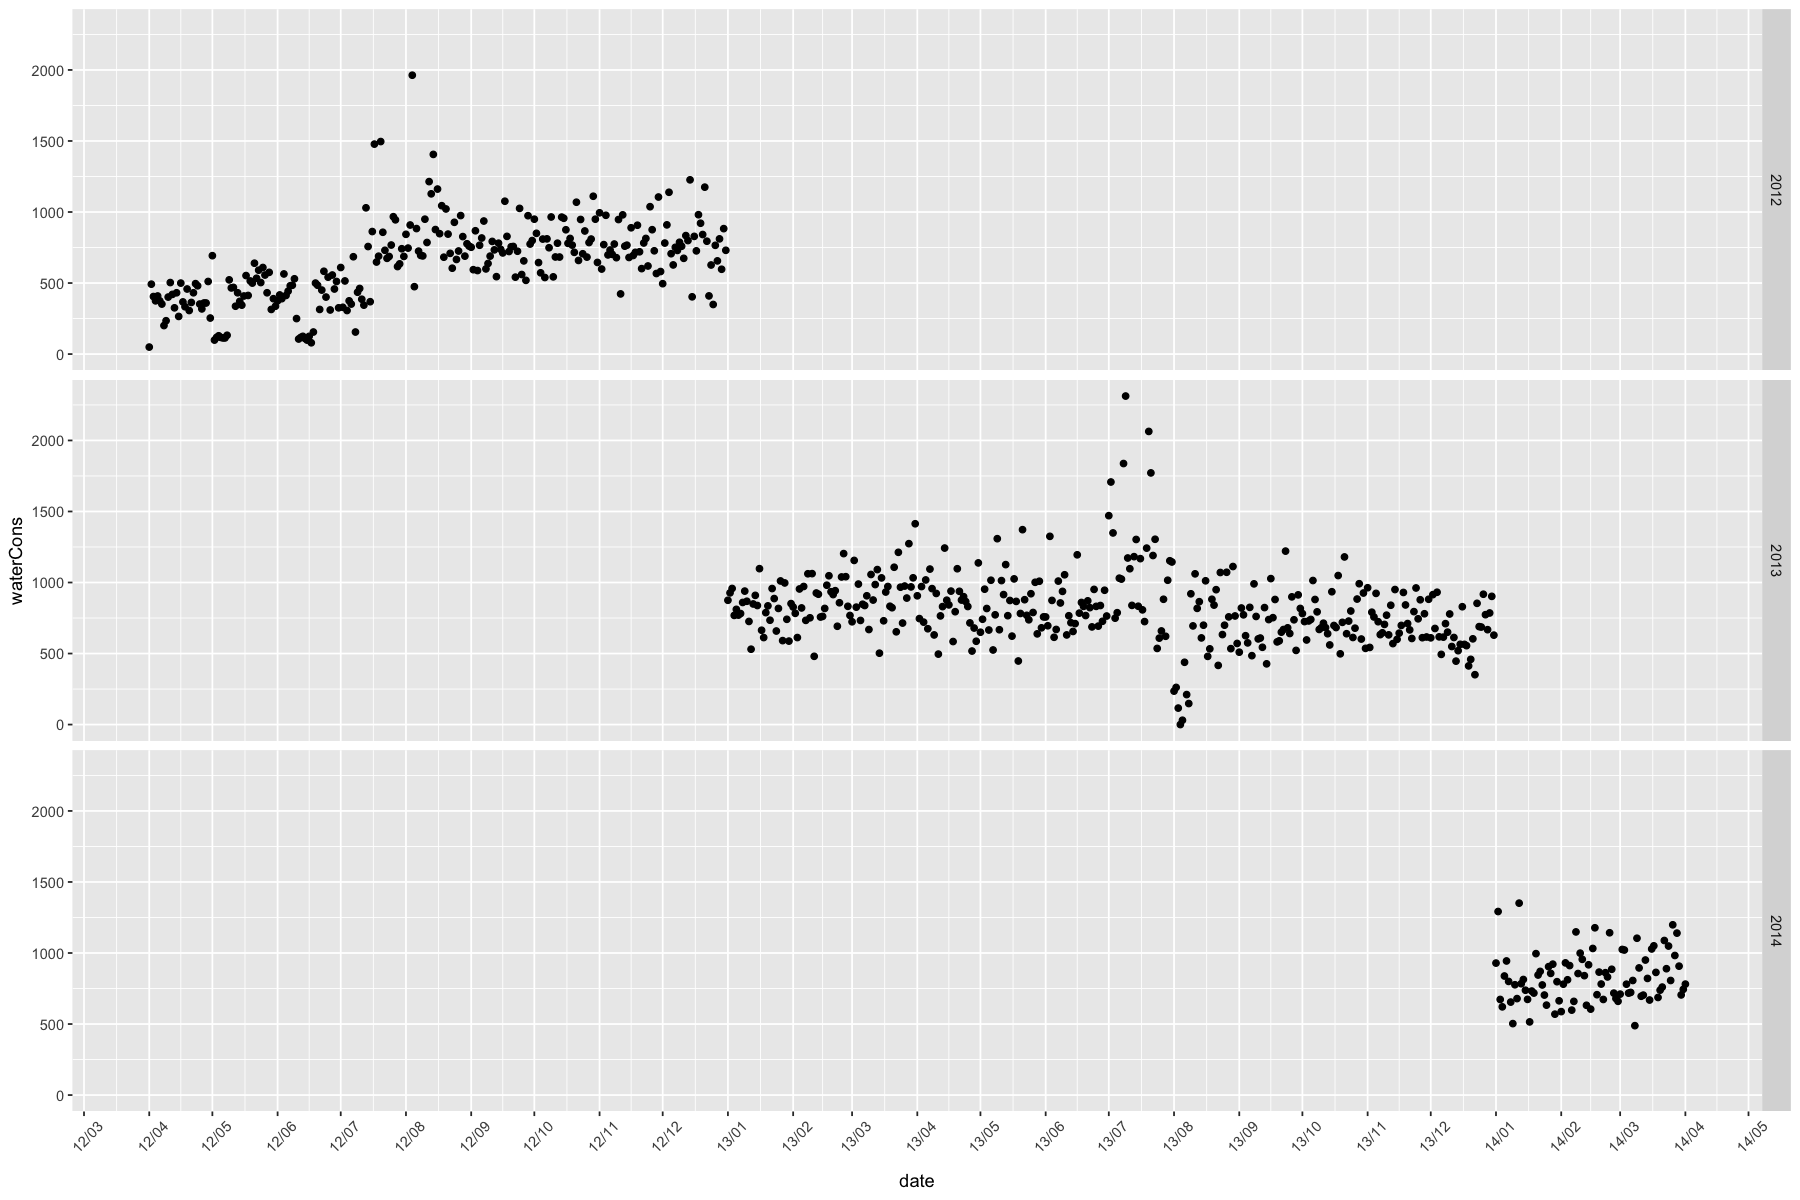

In [73]:
options(repr.plot.width = 15, repr.plot.height = 10)
ggplot(whwByDateDF, aes(x = date, y = waterCons)) +
    geom_point() +
    scale_x_date(
        labels = date_format("%y/%m"),
        breaks = date_breaks("months")
    ) +
    facet_grid(year ~ .) + 
    theme(
        axis.text.x = element_text(angle=45, margin=margin(10,0,0,0))
    )